<a href="https://colab.research.google.com/github/amrax10/Upload-notebook/blob/main/3day.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

df.head()

Saving movies.csv to movies (1).csv


,star_rating,title,content_rating,genre,duration,actors_list
0,9.3,The Shawshank Redemption,R,Crime,142,"[u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt..."
1,9.2,The Godfather,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']"
2,9.1,The Godfather: Part II,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv..."
3,9.0,The Dark Knight,PG-13,Action,152,"[u'Christian Bale', u'Heath Ledger', u'Aaron E..."
4,8.9,Pulp Fiction,R,Crime,154,"[u'John Travolta', u'Uma Thurman', u'Samuel L...."


In [15]:
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 979 entries, 0 to 978
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   title        979 non-null    object 
 1   star_rating  979 non-null    float64
 2   genre        979 non-null    object 
 3   duration     979 non-null    int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 30.7+ KB


Index(['title', 'star_rating', 'genre', 'duration'], dtype='object')

In [13]:
df = df[['title', 'star_rating', 'genre', 'duration']]
df.head()

,title,star_rating,genre,duration
0,The Shawshank Redemption,9.3,Crime,142
1,The Godfather,9.2,Crime,175
2,The Godfather: Part II,9.1,Crime,200
3,The Dark Knight,9.0,Action,152
4,Pulp Fiction,8.9,Crime,154


In [17]:
df = df.dropna()
df = df.drop_duplicates()

In [18]:
top_movies = df.sort_values(by='star_rating', ascending=False).head(10)
top_movies

,title,star_rating,genre,duration
0,The Shawshank Redemption,9.3,Crime,142
1,The Godfather,9.2,Crime,175
2,The Godfather: Part II,9.1,Crime,200
3,The Dark Knight,9.0,Action,152
4,Pulp Fiction,8.9,Crime,154
9,Fight Club,8.9,Drama,139
8,Schindler's List,8.9,Biography,195
6,"The Good, the Bad and the Ugly",8.9,Western,161
7,The Lord of the Rings: The Return of the King,8.9,Adventure,201
5,12 Angry Men,8.9,Drama,96


In [20]:
print("Average Rating:", df['star_rating'].mean())

Average Rating: 7.889785495403474


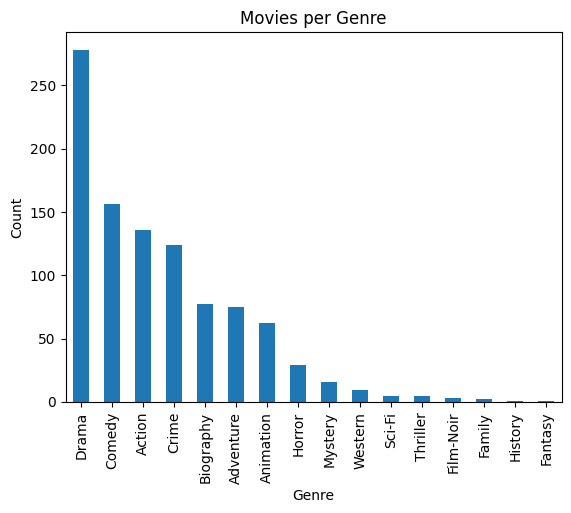

In [21]:
genre_count = df['genre'].value_counts()

genre_count.plot(kind='bar')
plt.title("Movies per Genre")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

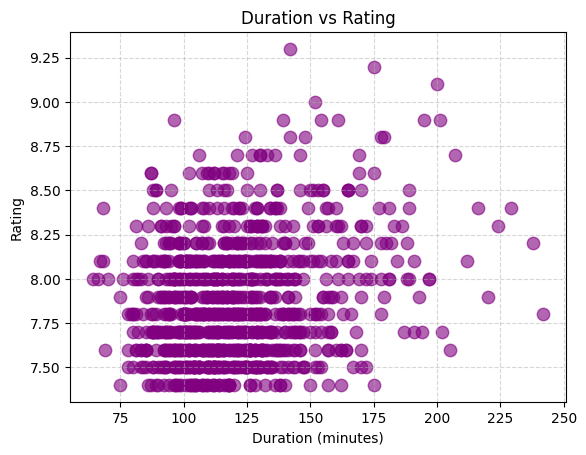

In [31]:
plt.scatter(df['duration'], df['star_rating'], color='purple', alpha=0.6, s=80)
plt.xlabel("Duration (minutes)")
plt.ylabel("Rating")
plt.title("Duration vs Rating")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

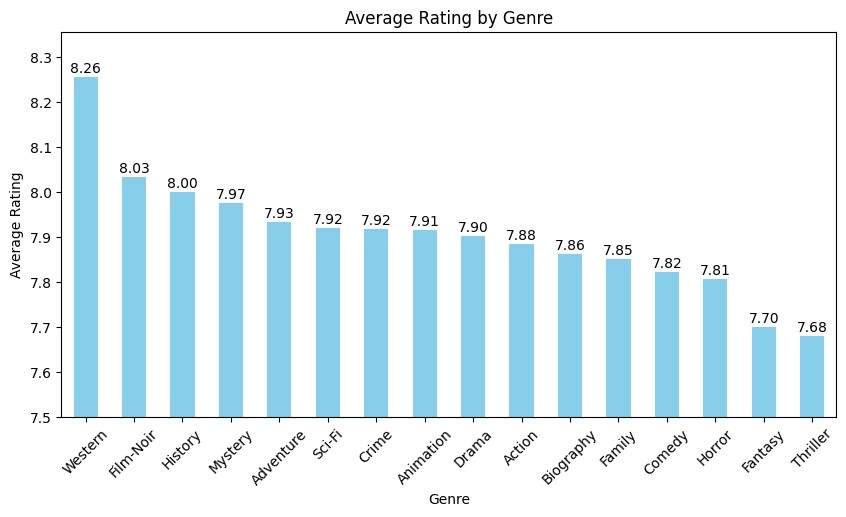

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Average rating per genre
avg_genre_rating = df.groupby('genre')['star_rating'].mean().sort_values(ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(10,5))
avg_genre_rating.plot(kind='bar', ax=ax, color='skyblue')

# Add actual decimal values on top of each bar
for i, v in enumerate(avg_genre_rating):
    ax.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=10)

# Customize y-axis: start at 7.5, end a little above the max value
min_rating = 7.5
max_rating = avg_genre_rating.max() + 0.1
ax.set_ylim(min_rating, max_rating)
ax.set_yticks(np.arange(min_rating, max_rating + 0.01, 0.1))  # ticks every 0.1

plt.title("Average Rating by Genre")
plt.ylabel("Average Rating")
plt.xlabel("Genre")
plt.xticks(rotation=45)
plt.show()


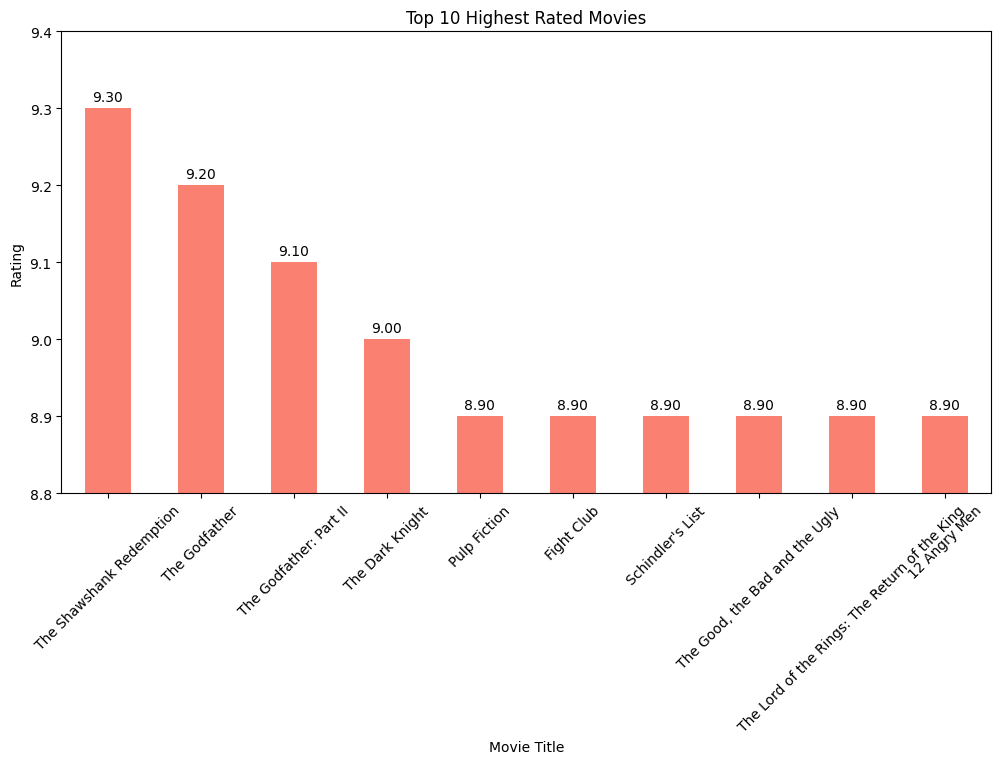

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Top 10 highest rated movies
top_movies = df.sort_values(by='star_rating', ascending=False).head(10)

# Plot
fig, ax = plt.subplots(figsize=(12,6))
top_movies.plot(x='title', y='star_rating', kind='bar', ax=ax, color='salmon', legend=False)

# Add decimal values on top of each bar
for i, v in enumerate(top_movies['star_rating']):
    ax.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=10)

# Dynamically adjust y-axis
min_rating = top_movies['star_rating'].min() - 0.1  # a little below lowest
max_rating = top_movies['star_rating'].max() + 0.1  # a little above highest

ax.set_ylim(min_rating, max_rating)

# Make ticks at 0.1 intervals
ax.set_yticks(np.arange(round(min_rating,1), round(max_rating+0.05,1), 0.1))

plt.title("Top 10 Highest Rated Movies")
plt.ylabel("Rating")
plt.xlabel("Movie Title")
plt.xticks(rotation=45)
plt.show()

Insights:

- Some genres have more movies than others.
- Average rating is around 7.
- Longer movies are not always better rated.
- Certain genres consistently get higher ratings.